In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

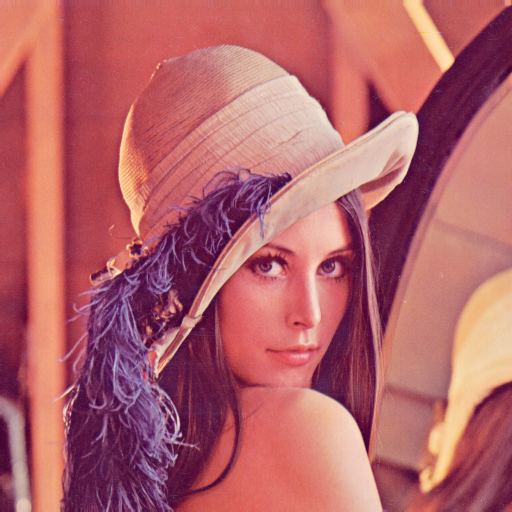

In [26]:
from google.colab.patches import cv2_imshow
img = cv2.imread('/content/Lenna_(test_image).png')
cv2_imshow( img)


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

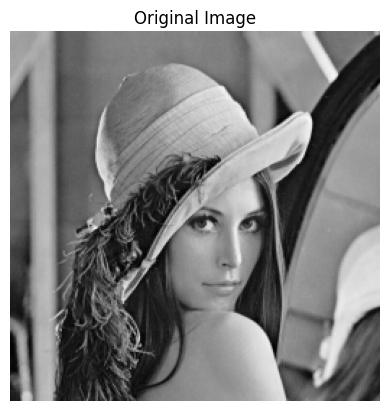

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load sample image (grayscale)
img = cv2.imread(cv2.samples.findFile('/content/Lenna_(test_image).png'), cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))

plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

In [17]:
# Smoothing kernels
mean_kernel = np.ones((3,3)) / 9

gaussian_kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
]) / 16

# Edge detection kernels
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

laplacian = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
])

# Sharpening kernel
sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# Emboss kernel
emboss = np.array([
    [-2, -1, 0],
    [-1,  1, 1],
    [ 0,  1, 2]
])

In [19]:
mean_blur = cv2.filter2D(img, -1, mean_kernel)
gaussian_blur = cv2.filter2D(img, -1, gaussian_kernel)

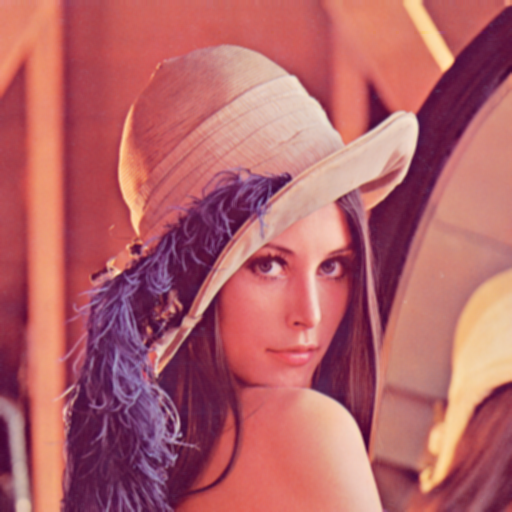

In [28]:
mean_img = cv2.filter2D(img, -1, mean_kernel)
cv2_imshow(mean_img)

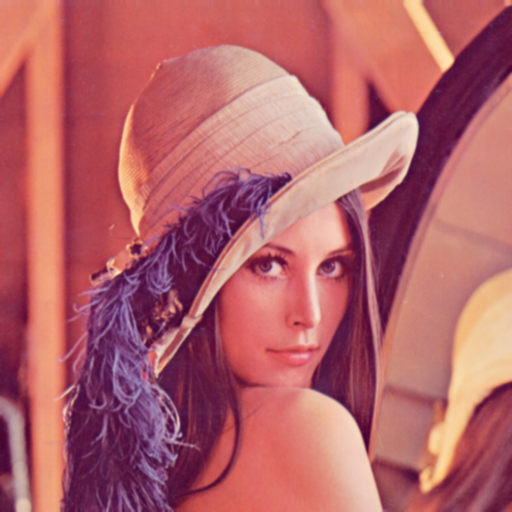

In [27]:
gauss_img = cv2.filter2D(img, -1, gaussian_kernel)
cv2_imshow(gauss_img)

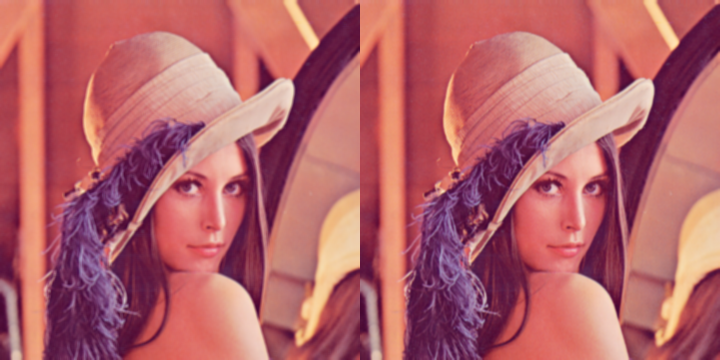

In [32]:
img = cv2.resize(img, (360, 360))
comparison = np.hstack((cv2.filter2D(img, -1, mean_kernel), cv2.filter2D(img, -1, gaussian_kernel)))
cv2_imshow(comparison)

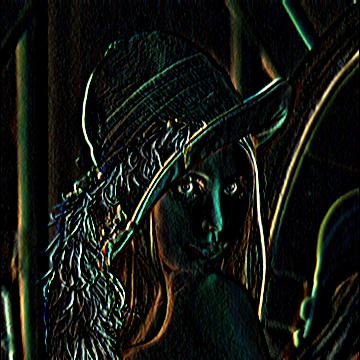

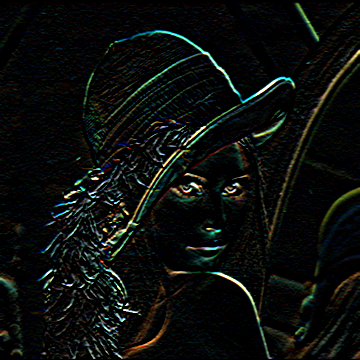

(None, None)

In [36]:
gx, gy = cv2.filter2D(img, -1, sobel_x), cv2.filter2D(img, -1, sobel_y)
cv2_imshow(gx), cv2_imshow(gy)

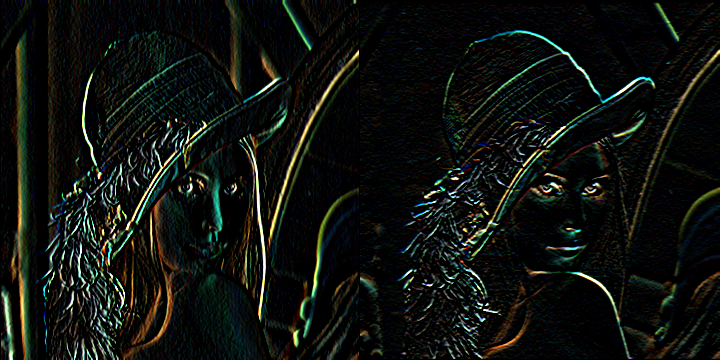

In [38]:
cv2_imshow(np.hstack((gx, gy)))

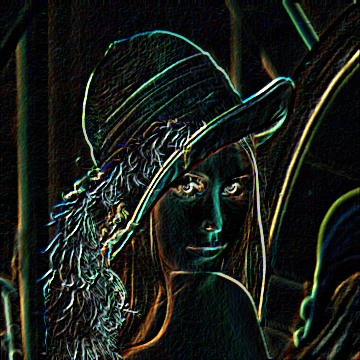

In [44]:
merged = cv2.addWeighted(gx, 0.8, gy, 0.8, 1)
cv2_imshow(merged)

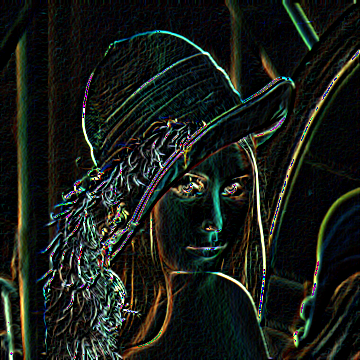

In [45]:
magnitude = cv2.magnitude(gx.astype(float), gy.astype(float)).astype('uint8')
cv2_imshow(magnitude)

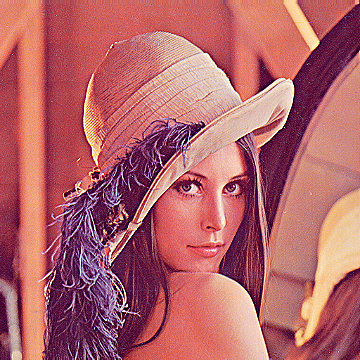

In [46]:
sharpenimg= cv2.filter2D(img, -1, sharpen)
cv2_imshow(sharpenimg) # image become more clearer

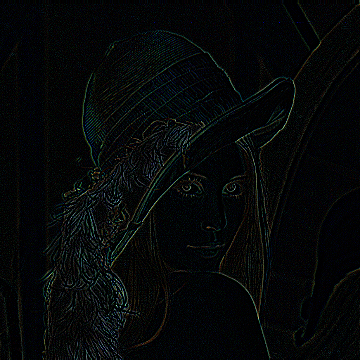

In [47]:
laplacianimg = cv2.filter2D(img, -1, laplacian)
cv2_imshow(laplacianimg)

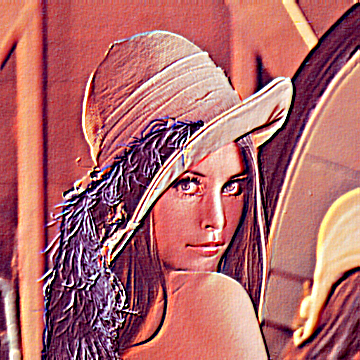

In [48]:
embossimg =cv2.filter2D(img, -1, emboss)
cv2_imshow(embossimg)

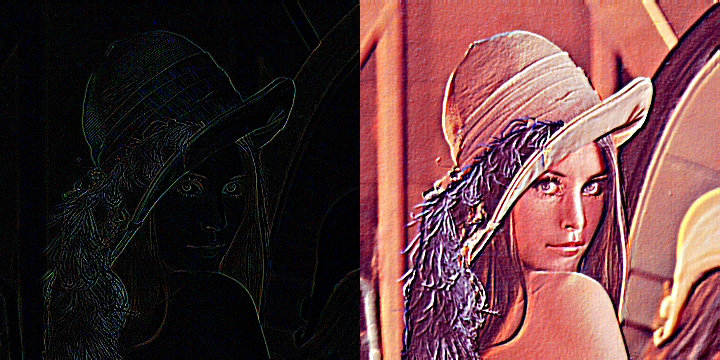

In [56]:
cv2_imshow(np.hstack((laplacianimg, embossimg))) #Laplacian (Edge Detection), Emboss (Depth & Texture)

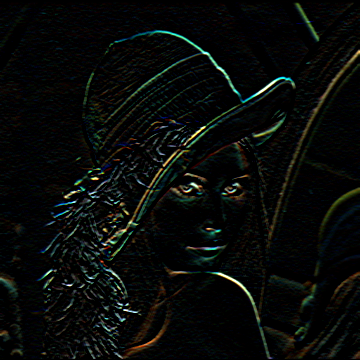

In [61]:

edge_kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

edge_img = cv2.filter2D(img, -1, edge_kernel)
cv2_imshow(edge_img) # determine the edge of image